In [14]:
import multiprocessing as mp
from functools import partial
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

import DMdecay as dmd
import JWSTutils as jwst
from gnz11_split import partition_gnz11

In [15]:
run_dir = "gnz11_split"
prev_config_path = F"{run_dir}/gnz11_split.toml"

In [16]:
prev_configs = dmd.prep.parse_configs(prev_config_path)
run_name = prev_configs["run"]["name"]

data = jwst.process_datafiles(prev_configs["run"]["paths"], 
                                prev_configs["system"]["res_path"])
data = partition_gnz11(data, prev_configs["run"]["lambda_min"],
                        prev_configs["run"]["lambda_split"])
for spec in data:
    dmd.prep.doppler_correction(spec, prev_configs["halo"])
    dmd.prep.add_Dfactor(spec, prev_configs["halo"])
    spec["sigma_v"] = prev_configs["halo"]["sigma_v"]

base_specset = dmd.prep.SpecSetfromList(data)

parsing gnz11_split/gnz11_split.toml
processing 2 datafiles...


In [17]:
for k, v in prev_configs.items():
    print(k)
    for kk, vv in v.items():
        print(f"  {kk}: {vv}")

run
  name: gnz11_split
  filenames: ['jw04426-o001_t001_nirspec_g235m-f170lp/jw04426-o001_t001_nirspec_g235m-f170lp_x1d.fits', 'jw04426-o001_t001_nirspec_g140m-f100lp/jw04426-o001_t001_nirspec_g140m-f100lp_x1d.fits']
  lambda_split: 1.65978
  lambda_min: 0.99
  rawlimits_filename: line-rawlimits.out
  bestfits_filename: line-bestfits.out
  pc_filename: line-pc.out
  lineoutput_filename: line-output.json
  fluxlimits_filename: flux-limits.out
  paths: ['data/mastDownload/JWST/jw04426-o001_t001_nirspec_g235m-f170lp/jw04426-o001_t001_nirspec_g235m-f170lp_x1d.fits', 'data/mastDownload/JWST/jw04426-o001_t001_nirspec_g140m-f100lp/jw04426-o001_t001_nirspec_g140m-f100lp_x1d.fits']
analysis
  width_factor: 150.0
  padding: 1e-08
  num_knots: 5
  chisq_step: 4.0
  limit_guess: [1e-05, 0.001]
  max_clip_iters: 100
  clipping_factor: 3.0
  Ntrials: 1000
  Nbins: 15
  power_threshold: 0.1587
  Nthreads: 7
  inflate: 1
  checkpoint: 30
halo
  rho_s: 0.18
  r_s: 24.0
  sigma_v_kms: 160.0
  r_sun: 8.

In [18]:
old_rawlimits = np.loadtxt(
    F"{run_name}/{prev_configs['run']['rawlimits_filename']}")
valid = np.isfinite(old_rawlimits[:, 1])
mass_to_test = old_rawlimits[valid, :][:, 0]
lam_to_test = dmd.conversions.mass_to_wavelength(mass_to_test)
Nlams = lam_to_test.shape[0]
exisitng_limit_invsec = old_rawlimits[valid, :][:, 1]
decayrate_to_test = \
    dmd.conversions.invsec_to_fluxscale(exisitng_limit_invsec)

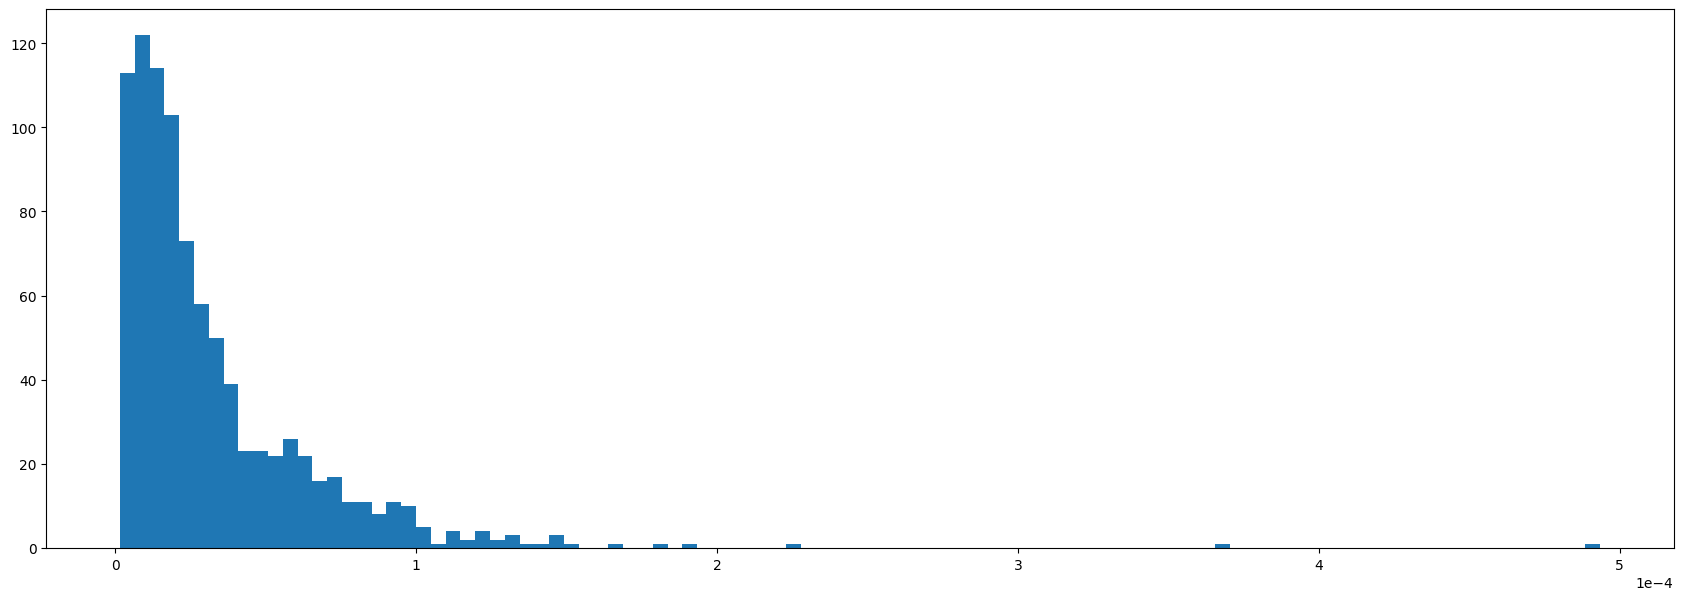

In [19]:
fig, ax = plt.subplots(figsize=(21, 7))
ax.hist(decayrate_to_test, bins=100)
np.quantile(decayrate_to_test, [0.1, 0.5, 0.9])
ax.axes.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

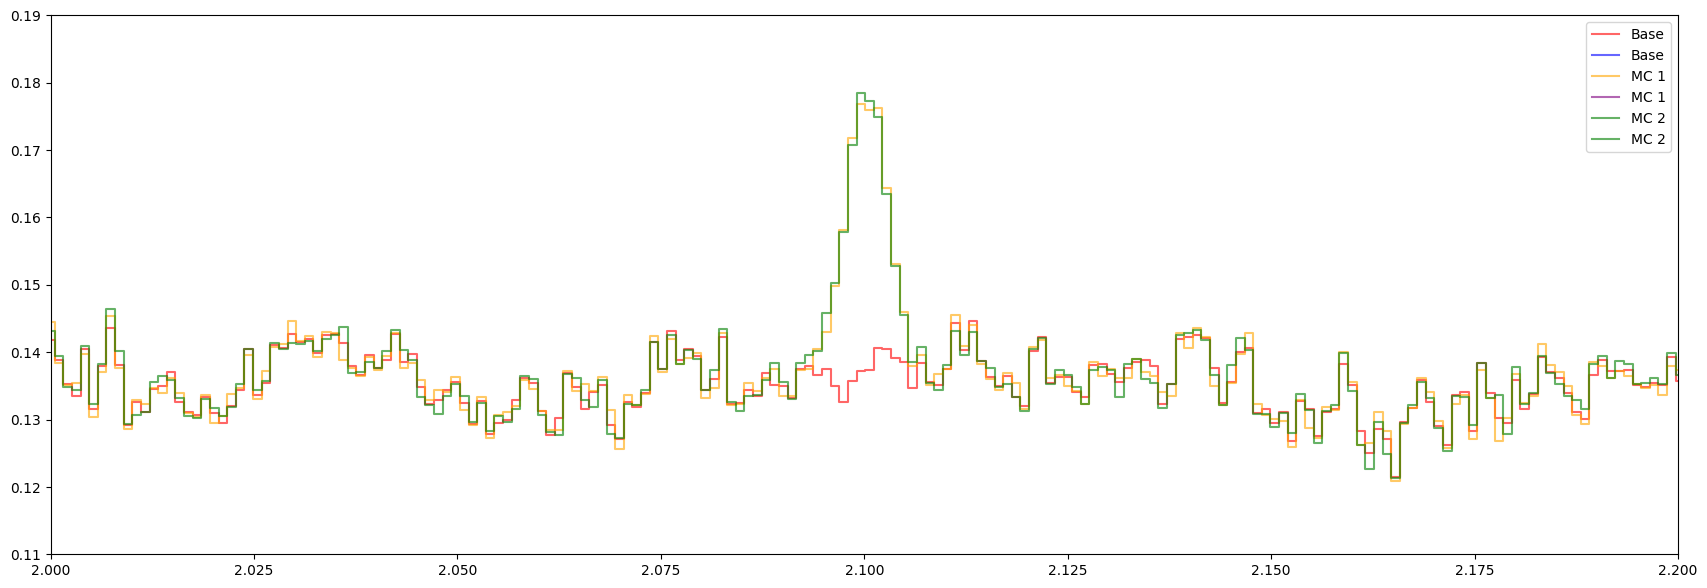

In [20]:
decayrate = 2e-4
lam0 = 2.1

new_specset = base_specset.add_DM_line(decayrate, lam0).resample_flux()

fig, ax = plt.subplots(figsize=(21, 7))
base_specset.plot(ax=ax, error_band=0, 
             distinct_plot_args=[{"color": "red"},
                                 {"color": "blue"}],
             alpha=0.6, label="Base")
new_specset.plot(ax=ax, error_band=0,
             distinct_plot_args=[{"color": "orange"},
                                 {"color": "purple"},],
             alpha=0.6, label="MC 1")

new_specset = base_specset.add_DM_line(decayrate, lam0).resample_flux()
new_specset.plot(ax=ax, error_band=0, color='green',
                alpha=0.6, label="MC 2")


ax.set_xlim(lam0 - 0.1, lam0 + 0.1)
ax.set_ylim(0.11, 0.19)
ax.legend()

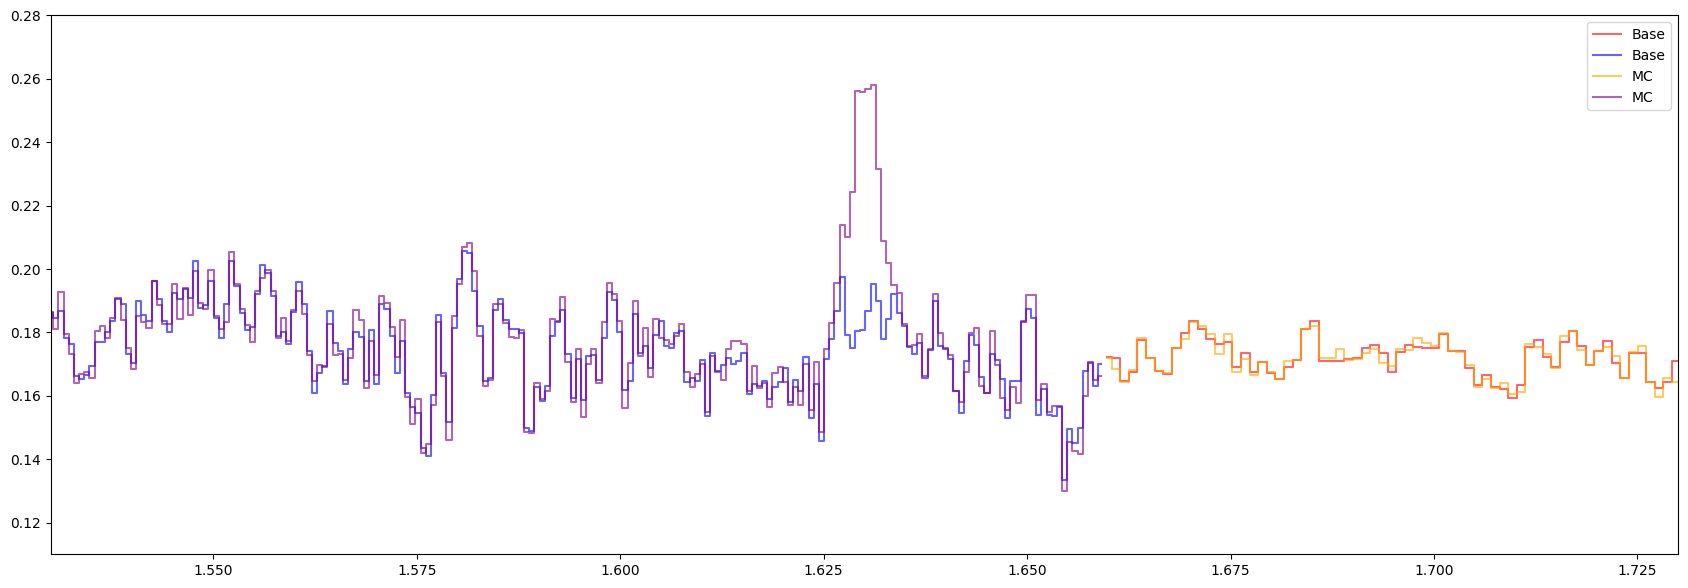

In [21]:
decayrate = 4e-4
lam0 = 1.63

new_specset = base_specset.add_DM_line(decayrate, lam0).resample_flux()

fig, ax = plt.subplots(figsize=(21, 7))
base_specset.plot(ax=ax, error_band=0, 
             distinct_plot_args=[{"color": "red"},
                                 {"color": "blue"}],
             alpha=0.6, label="Base")
new_specset.plot(ax=ax, error_band=0,
             distinct_plot_args=[{"color": "orange"},
                                 {"color": "purple"}],
             alpha=0.6, label="MC")
ax.set_xlim(lam0 - 0.1, lam0 + 0.1)
ax.set_ylim(0.11, 0.28)
ax.legend()

In [22]:
keys_for_linesearch = {
    "analysis":[
      "width_factor", 
      "padding", 
      "num_knots", 
      "chisq_step", 
      "limit_guess", 
      "max_clip_iters", 
      "clipping_factor", 
      "Ntrials", 
      "Nbins", 
      "power_threshold"],
    "halo":[ 
      "sigma_v"]}
linesearch_configs = {k:prev_configs[k1][k] 
                       for k1, l1 in keys_for_linesearch.items()
                       for k in l1
                       if k in prev_configs[k1].keys()} 

print("linsearch configs used in v1:")
for k, v in linesearch_configs.items():
    print(f"    {k} = {v}")
print()
default_setup = dmd.linesearch.LineSearchSetup(**linesearch_configs)

# linesearch_configs["num_knots"] = 5
linesearch_configs["width_factor"] = 20
narrow_setup = dmd.linesearch.LineSearchSetup(**linesearch_configs)

setups = {"default":default_setup, "narrow":narrow_setup}
print("running below with:")
for n, d in setups.items():
    print(f"    {n}:")
    for k, v in d.__dict__.items():
        print(f"        {k} = {v}")

linsearch configs used in v1:
    width_factor = 150.0
    padding = 1e-08
    num_knots = 5
    chisq_step = 4.0
    limit_guess = [1e-05, 0.001]
    max_clip_iters = 100
    clipping_factor = 3.0
    Ntrials = 1000
    Nbins = 15
    power_threshold = 0.1587
    sigma_v = 0.0005337025523170433

running below with:
    default:
        width_factor = 150.0
        padding = 1e-08
        num_knots = 5
        chisq_step = 4.0
        limit_guess = [1e-05, 0.001]
        max_clip_iters = 100
        clipping_factor = 3.0
        Ntrials = 1000
        Nbins = 15
        power_threshold = 0.1587
        sigma_v = 0.0005337025523170433
    narrow:
        width_factor = 20
        padding = 1e-08
        num_knots = 5
        chisq_step = 4.0
        limit_guess = [1e-05, 0.001]
        max_clip_iters = 100
        clipping_factor = 3.0
        Ntrials = 1000
        Nbins = 15
        power_threshold = 0.1587
        sigma_v = 0.0005337025523170433


In [23]:
import sys 
print(sys.version)
print(np.__version__)
import scipy 
print(scipy.__version__)
import matplotlib 
print(matplotlib.__version__)
import astropy 
print(astropy.__version__)
import pandas
print(pandas.__version__)

3.10.12 (main, Mar 22 2024, 16:50:05) [GCC 11.4.0]
1.24.2
1.9.3
3.7.1
5.3
2.1.3


fit 0.0001 line at 2.1

example fit using default:
  init decayrate: 6.29e-04
  Chisq/dof: 17.632472972551795
363
[[1.90445584 2.29554416]
 [       nan        nan]]
[[0.15317359 0.13964398 0.13545591 0.13324707 0.12122037]]
0.00010930068433621451
[0.00235407 0.00140402]

example fit using narrow:
  init decayrate: 6.29e-04
  Chisq/dof: 9.46656034537989
44
[[2.07392745 2.12607255]
 [       nan        nan]]
[[0.14188067 0.13532534 0.13698649 0.13819129 0.1351368 ]]
9.920263900663883e-05
[0.00235407 0.00140402]



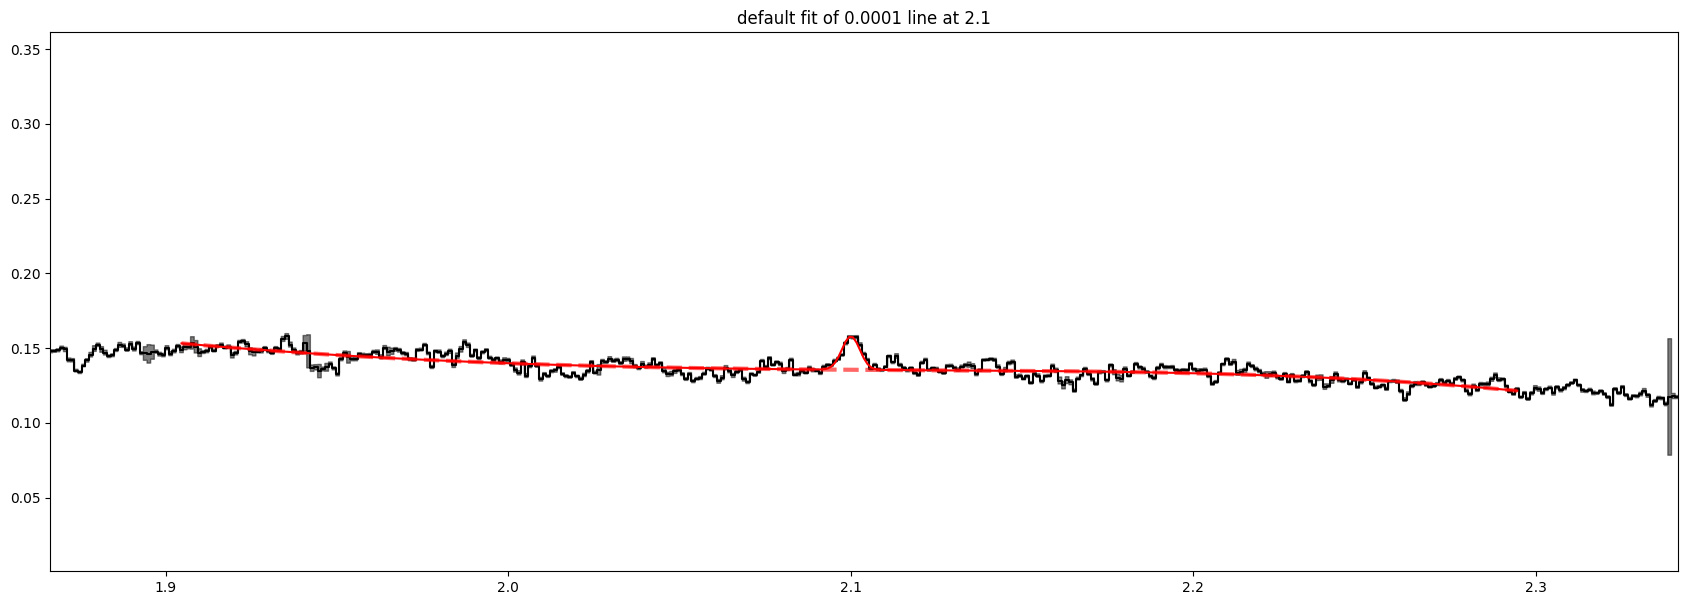

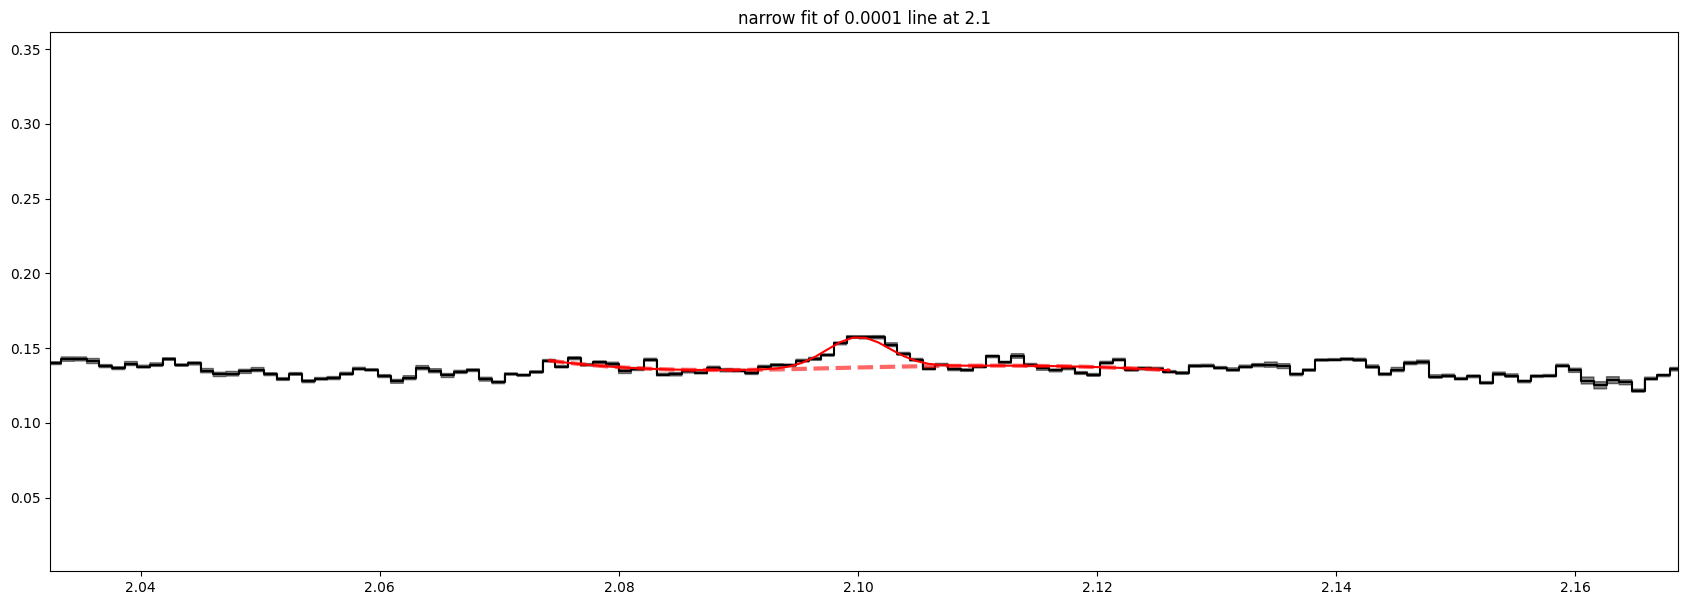

In [24]:
decayrate = 1e-4 #3e-4 # 1e-4 1e-4
lam0 = 2.1 #1.45 #2.8 #2.1
print(f"fit {decayrate} line at {lam0}\n")

for name, setup in setups.items():
    print(f"example fit using {name}:")
    new_specset = base_specset.add_DM_line(decayrate, lam0)\
                            #   .resample_flux()
    searcher = dmd.linesearch.LineSearcher(setup, new_specset, lam0)
    print(f"  init decayrate: {searcher.decayrate_init:0.2e}")
    eg_knot_vals, eg_decayrate = searcher.fit_continuum_plus_line()
    chisq_dof = \
        searcher.chisq(eg_knot_vals, eg_decayrate)/ \
        searcher.dof_continuum_plus_line
    print(f"  Chisq/dof: {chisq_dof}")
    print(searcher.dof_continuum_plus_line)
    print(f"{searcher.fit_intervals}")
    print(eg_knot_vals)
    print(eg_decayrate)
    print(searcher.data.inst_res)
    print()
    
    fig, ax = plt.subplots(figsize=(21, 7))
    new_specset.plot(ax=ax, error_band=0.5, color='black', alpha=1)
    model = searcher.spline_plus_line_model(eg_knot_vals, eg_decayrate, 
                                            searcher.lams_to_fit)
    model_continuum_only = searcher.spline_plus_line_model(eg_knot_vals, 0,
                                                        searcher.lams_to_fit)
    for i_model, i_specs in enumerate(searcher.to_fit):
        ax.plot(searcher.lams_to_fit[i_specs], model[i_model], color="red")
        ax.plot(searcher.lams_to_fit[i_specs], model_continuum_only[i_model], 
                color="red", alpha=0.6, linewidth=3, linestyle='dashed')
    ax.set_xlim(*searcher.get_plot_limits(margin=0.02))
    ax.set_title(F"{name} fit of {decayrate} line at {lam0}")

In [25]:
index = np.argmin(np.abs(searcher.data.lam[0] - lam0))
print(f"index = {index}")
print(f"lam = {searcher.data.lam[0][index]}")
print(f"flux = {searcher.data.flux[0][index]}")
print(f"error = {searcher.data.error[0][index]}")

index = 415
lam = 2.0995760186978774
flux = 0.15738701781731906
error = 0.00089966216324324


In [26]:
n_trials = 10**3
error_scales = np.array([1, np.sqrt(chisq_dof)])
bf_decayrates_dict = {
    setup_name:np.full((n_trials, error_scales.size), np.nan)
    for setup_name in setups.keys()}
for setup_name, setup in setups.items():
    for i, scale_factor in enumerate(error_scales):
        for j in tqdm(range(n_trials)):
            trial_specset = base_specset.add_DM_line(decayrate, lam0)\
                                        .rescale_error(scale_factor)\
                                        .resample_flux()
            searcher = dmd.linesearch.LineSearcher(setup, trial_specset, lam0)
            bf_knot_vals, bf_decayrate = searcher.fit_continuum_plus_line(
                try_unconstrained=False 
            )
            bf_decayrates_dict[setup_name][j, i] = bf_decayrate

100%|██████████| 1000/1000 [00:41<00:00, 24.18it/s]


In [27]:
print(f"input decayrate: {decayrate:.2e}\n")

quants = {setup_name:np.quantile(bf_decayrates, [0.025, 0.5, 0.975], axis=0)
          for setup_name, bf_decayrates in bf_decayrates_dict.items()}
sigma = {setup_name:(quants[setup_name][2, :] - quants[setup_name][0, :])/2
         for setup_name in quants.keys()}
diff_width = {
    setup_name:np.abs(quants[setup_name][1, :] - decayrate)/sigma[setup_name]
    for setup_name in quants.keys()}
for setup_name in bf_decayrates_dict:
    print(F"{setup_name} results:")
    for i, scale_factor in enumerate(error_scales):
        print(f"  with error scaling {scale_factor:.2f}:\n"
            f"      output decayrate: "
            f"{quants[setup_name][1, i]:.2e} +/- {sigma[setup_name][i]:.2e}\n"
            f"            diff/width: {diff_width[setup_name][i]:0.2f}\n"
            f"                uppper: {quants[setup_name][2, i]:.2e}")
    print()

input decayrate: 1.00e-04

default results:
  with error scaling 1.00:
      output decayrate: 1.09e-04 +/- 4.76e-06
            diff/width: 1.94
                uppper: 1.14e-04
  with error scaling 3.08:
      output decayrate: 1.09e-04 +/- 1.43e-05
            diff/width: 0.66
                uppper: 1.24e-04

narrow results:
  with error scaling 1.00:
      output decayrate: 9.93e-05 +/- 6.67e-06
            diff/width: 0.10
                uppper: 1.06e-04
  with error scaling 3.08:
      output decayrate: 9.94e-05 +/- 2.16e-05
            diff/width: 0.03
                uppper: 1.23e-04



Text(0.5, 0.98, 'injection recovery: 1.00e-04 line at 2.1')

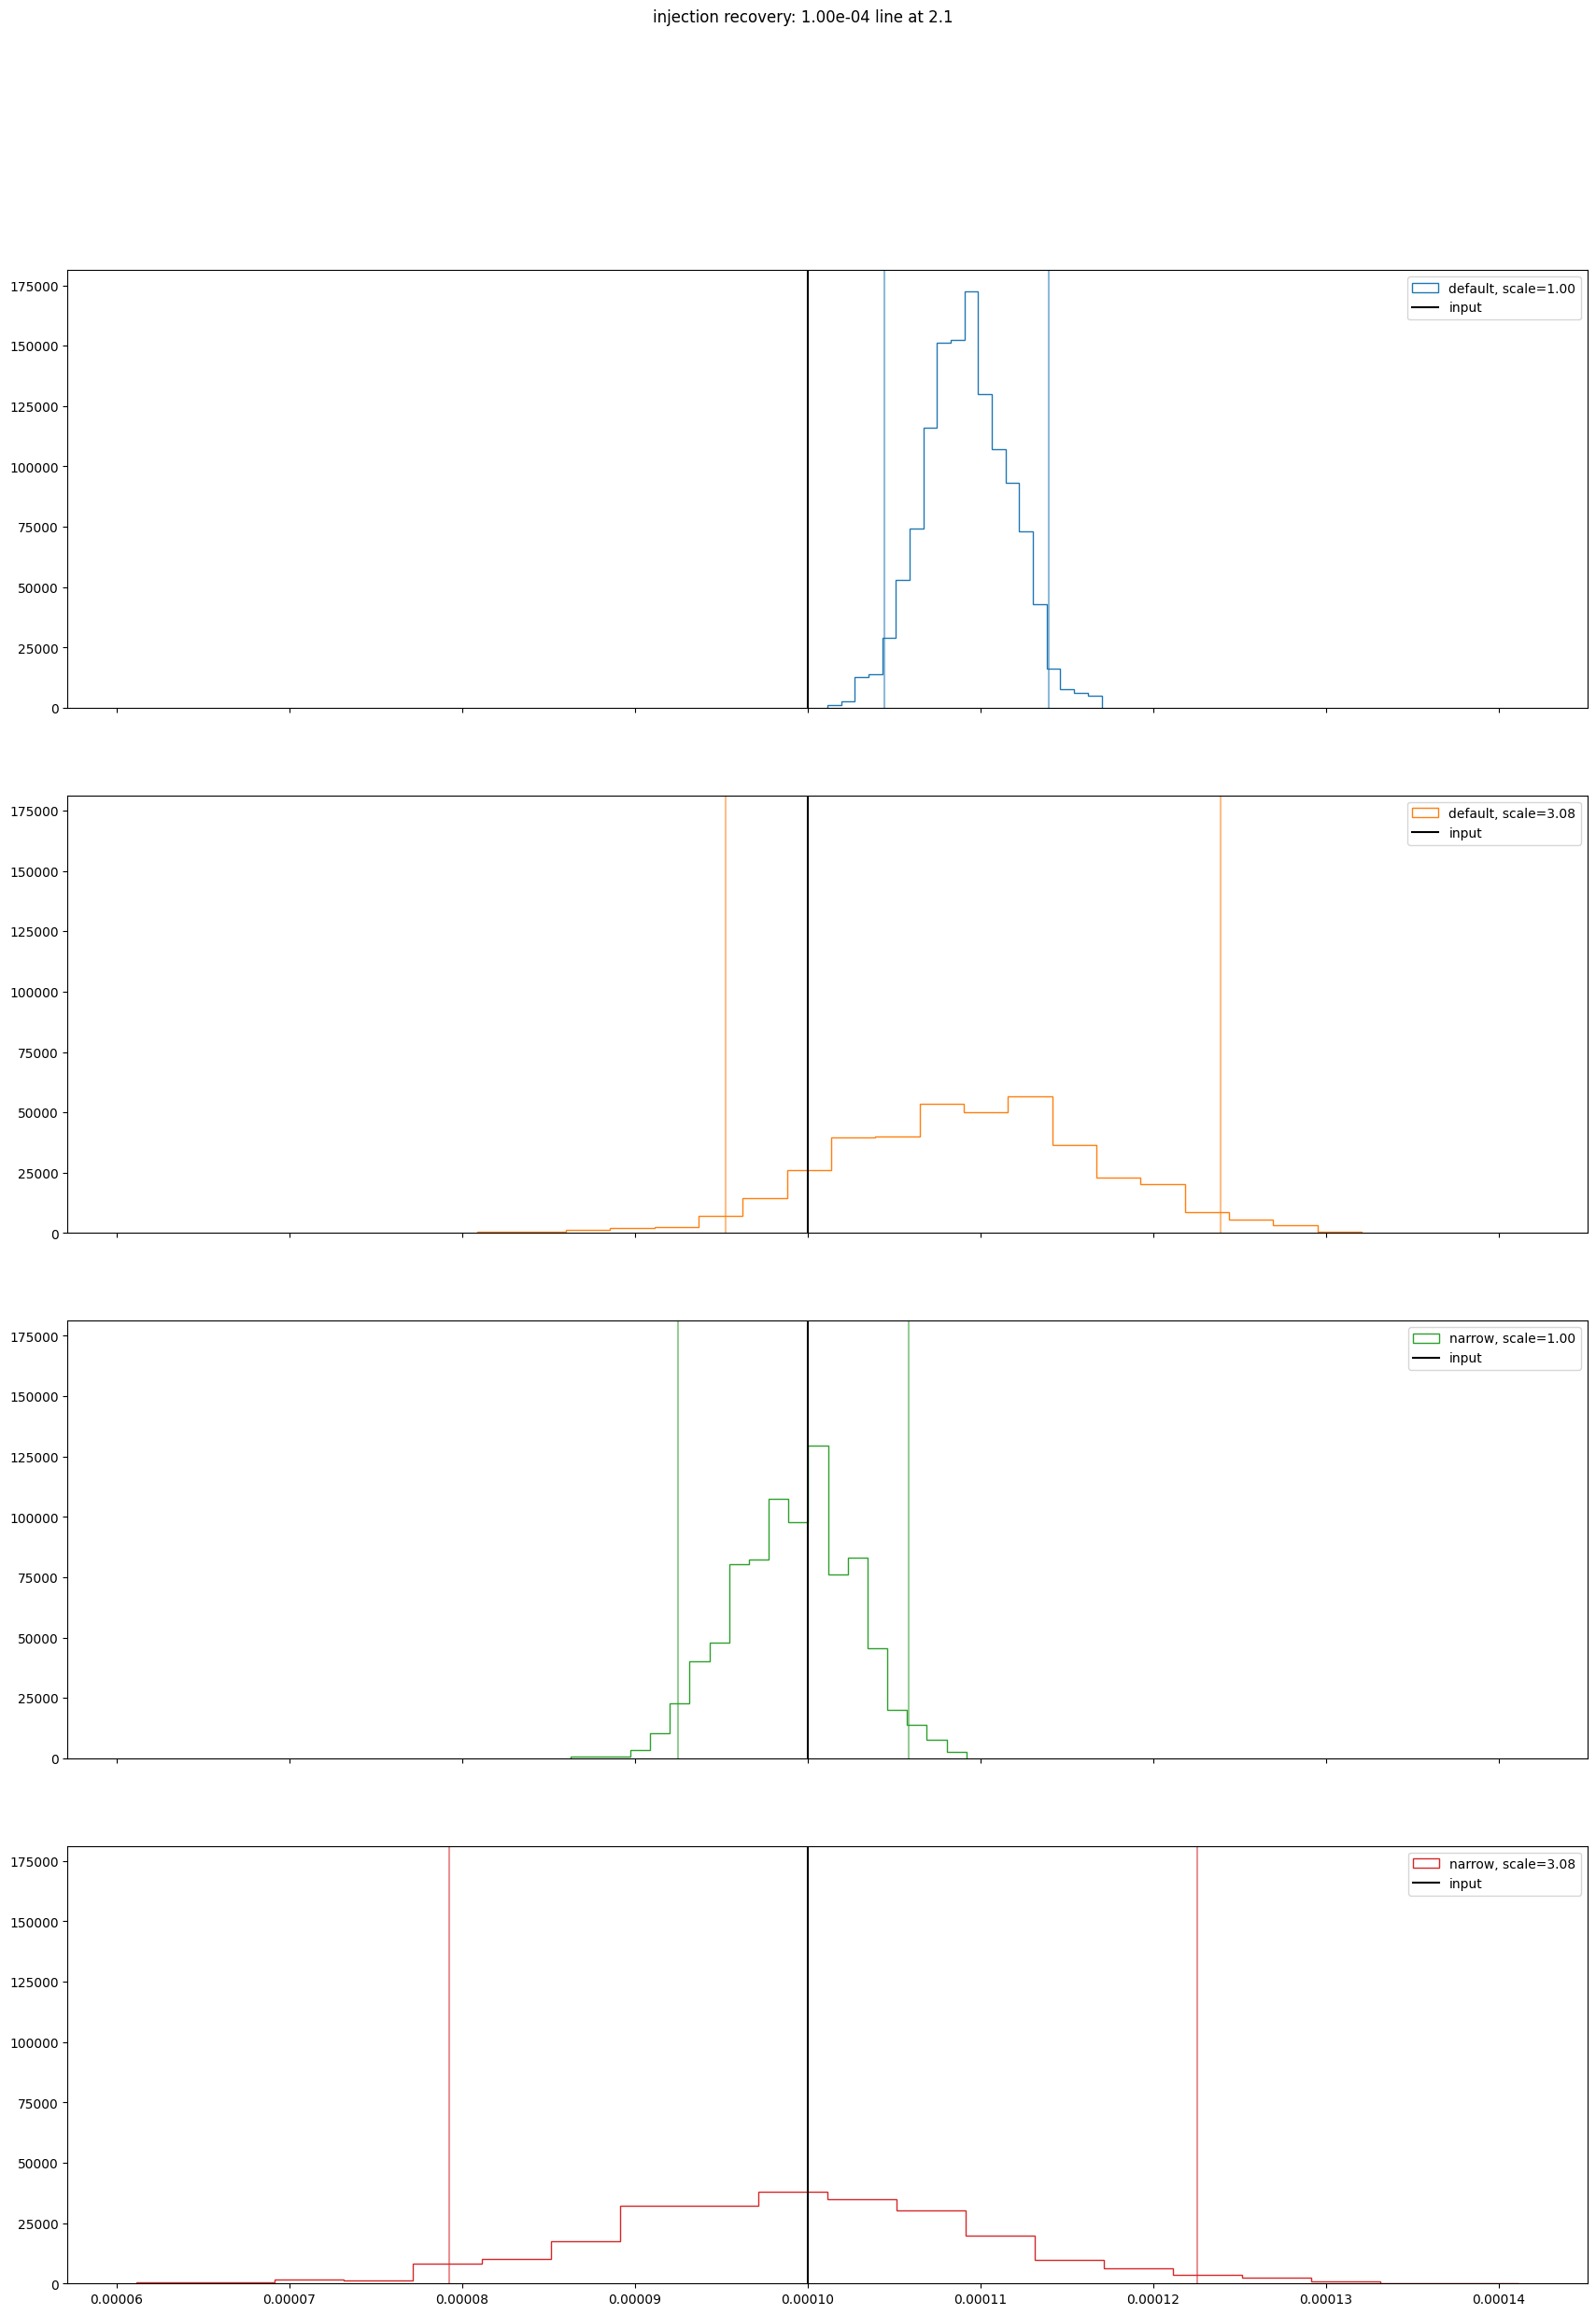

In [28]:
fig, axes = plt.subplots(len(setups)*error_scales.size,
                         sharex=True, sharey=True, 
                         figsize=(21, 4*7))
cmap = plt.get_cmap("tab10")
k = 0
for setup_name, bf_decayrates in bf_decayrates_dict.items():
    for i, scale_factor in enumerate(error_scales):
        axes[k].hist(bf_decayrates[:, i], bins=20, density=True, 
                     color=cmap(k), histtype='step', align='mid',
                     label=f"{setup_name}, scale={scale_factor:0.2f}")
        [axes[k].axvline(v, color=cmap(k), alpha=0.5) 
         for v in quants[setup_name][[0, 2], i]]
        axes[k].axvline(decayrate, color='black', 
                        linestyle='solid', label="input")
        axes[k].legend()
        k += 1
fig.suptitle(f"injection recovery: {decayrate:.2e} line at {lam0}")

In [29]:
# lam0 = 1.45 # 2.1 2.8
n_steps = 30
decayrates_to_test = np.geomspace(1e-6, 1e-3, n_steps)
n_trials = 100

line_specset = base_specset.add_DM_line(decayrate, lam0)
searcher = dmd.linesearch.LineSearcher(narrow_setup, line_specset, lam0)
eg_knot_vals, eg_decayrate = searcher.fit_continuum_plus_line()
chisq_dof = \
    searcher.chisq(eg_knot_vals, eg_decayrate)/searcher.dof_continuum_only
outputs = np.full(decayrates_to_test.size, np.nan)
errors = np.full(decayrates_to_test.size, np.nan)
for i, dr in tqdm(enumerate(decayrates_to_test)):
    trial_results = np.full(n_trials, np.nan)
    for j in range(n_trials):
        trial_specset = base_specset.add_DM_line(dr, lam0)\
                                    .rescale_error(np.sqrt(chisq_dof))\
                                    .resample_flux()
        searcher = dmd.linesearch.LineSearcher(narrow_setup, 
                                               trial_specset, lam0)
        _, trial_results[j] = searcher.fit_continuum_plus_line()
    outputs[i] = np.median(trial_results)
    errors[i] = (np.quantile(trial_results, 0.975) - 
                 np.quantile(trial_results, 0.025))/2
    

30it [03:15,  6.52s/it]


Text(0.5, 1.0, 'decayrate recovery at 2.1')

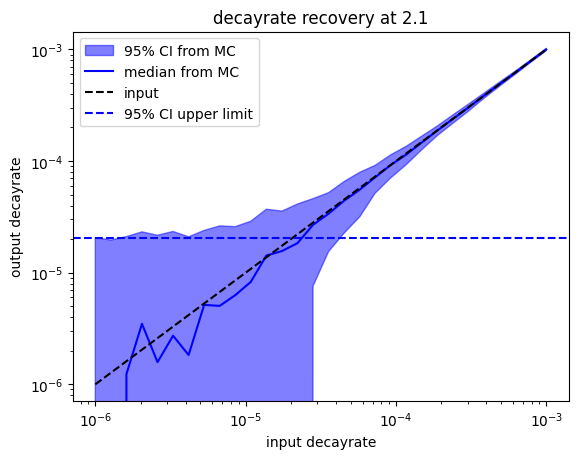

In [30]:
fig, ax = plt.subplots()

ax.fill_between(decayrates_to_test, outputs - errors, outputs + errors,
                color='blue', alpha=0.5, label="95% CI from MC")
ax.plot(decayrates_to_test, outputs, color='blue', label="median from MC")
ax.plot(decayrates_to_test, decayrates_to_test, color='black',
        linestyle='dashed', label="input")
ax.axhline(outputs[0] + errors[0], color='blue', linestyle='dashed',
           label="95% CI upper limit")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("input decayrate")
ax.set_ylabel("output decayrate")
ax.legend()
ax.set_title(F"decayrate recovery at {lam0}")